In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [56]:
#reading P2 continuous data
P2hobodf = pd.read_csv("P5_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv with the name of yoru csv with all the continuous hobo data
P2hobodf["Date-Time"] = pd.to_datetime(P2hobodf["Date-Time"]) #"Date-Time" is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
P2date = P2hobodf["Date-Time"] #this names the variable "date"
P2hobodfdate = P2date[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.


In [57]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
P2filteredhobo = hampel(P2hobodf["Temperature"], window_size=6, n_sigma=1.5) #filtering the data: for every point, a window of six data points on either side is applied, and the point is comparted to the median absolute deviation (with 1.5 standard deviations). If the data falls outside the MAD, it is counted as an outlier and removed. filteredhobo is a placeholder.
P2filteredhoboseries = pd.Series(P2filteredhobo.filtered_data, index = P2hobodf.index) #the hampel filter changes the type of data, and this forces it back into a panda series. filteredhoboseries is a placeholder. 
P2filteredhobo = P2filteredhoboseries[1:] #the hampel filter cannot remove the first data point (which I think is padded by zeroes), so I manually sliced it off. The variable is rewritten here to be called filteredhobo, which, after running this cell should be the continuous data without the spikes, forced back into a series, with the first data point removed. 


In [58]:
#reading the manual data
mandf = pd.read_csv("P5ManualData.csv", index_col=False) #Well_Sampling_Data_P1.csv is a placeholder for the csv file with the field measurements from the piezometer of interest. mandf is the placeholder for the dataframe with all of the manual field measurements. 
mandf.loc[:,"Temp bottom before"] #selects the column in the manual data csv that you want on the y-axis. Temp bottom before is a placeholder for whichever column you'd like to see.
mandf["Date"] = pd.to_datetime(mandf["Date"]) #converts the manual date-time values to pandas datetime format. 

In [68]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDam2Since2024.csv") #"NOAAHastingsDam2.csv" is a placeholder for the csv with your weather data
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])

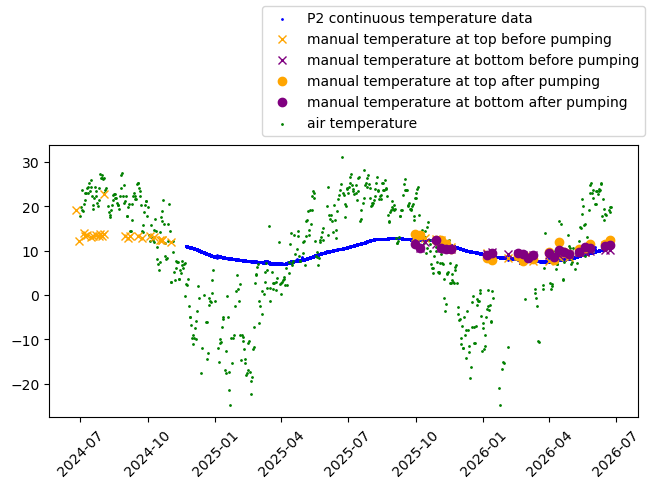

In [70]:
fig, ax = plt.subplots(layout='constrained')
plt.scatter(P2hobodfdate, P2filteredhobo, s = 1, color = "blue", label = "P2 continuous temperature data")
ax.plot(mandf.Date, mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime) and mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"]). 
ax.plot(mandf.Date, mandf.loc[:,"Temp bottom before"], 'x', color = "purple", label = "manual temperature at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"Temp bottom after"], 'o', color = "purple", label = "manual temperature at bottom after pumping")
plt.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], s = 1, color = "green", label = "air temperature")
plt.xticks(rotation=45)
# plt.ylim((-5, 20))
# plt.xlim((pd.to_datetime("2026-02-18"), pd.to_datetime("2026-02-20")))

fig.legend(loc='outside upper right')
plt.show;